In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
#from llm_passage_ranking.utils.eval_utils import get_trec_metric_values_from_method_df
#from llm_passage_ranking.utils.eval_utils import get_runtimes
from pathlib import Path

# Get metric funcs

In [3]:
def get_auc_pr(method_path):
    try:
        init_macro_df_path = f"{method_path}/all_query_macro_init_order_scores.tsv"
        df = pd.read_csv(init_macro_df_path, sep='\t')
        if 'macro_auc_score' in df:
            return df['macro_auc_score'].mean() * 100
        else:
            print(f"{init_macro_df_path} does not have a macro_auc_score column")
            return 0
    except FileNotFoundError:
        print(f"File not found: {method_path}")
        return 0

In [4]:
def get_ndcg_at_k(method_path,k):
    try:
        trec_results_path = os.path.join(method_path, "all_queries_eval_results.jsonl")
        if os.path.exists(trec_results_path):
            with open(trec_results_path, "r") as file:
                trec_results = [json.load(file)]
                #print(f"Loaded {len(trec_results)} results from {trec_results_path}")
            trec_df = pd.DataFrame(trec_results)

            # Remove std columns
            trec_df = trec_df[[col for col in trec_df.columns if not col.startswith("std_dev_")]]
            # Remove "mean_" prefix from column names
            trec_df.columns = [col.replace("mean_", "") for col in trec_df.columns]

            ndcg_at_k = trec_df[f"ndcg_cut_{k}"][0]*100

            return ndcg_at_k

    except FileNotFoundError:
        print(f"NDCG File not found: {method_path}")
        return 0

In [5]:
def get_ndcg_up_to_k(method_path,k):
    try:
        trec_results_path = os.path.join(method_path, "all_queries_eval_results.jsonl")
        if os.path.exists(trec_results_path):
            with open(trec_results_path, "r") as file:
                trec_results = [json.load(file)]
                #print(f"Loaded {len(trec_results)} results from {trec_results_path}")
            trec_df = pd.DataFrame(trec_results)

            # Remove std columns
            trec_df = trec_df[[col for col in trec_df.columns if not col.startswith("std_dev_")]]
            # Remove "mean_" prefix from column names
            trec_df.columns = [col.replace("mean_", "") for col in trec_df.columns]
            
            ndcg_columns = [f"ndcg_cut_{i}" for i in range(1, k+1)]

            ndcg_vals = trec_df[ndcg_columns].values

            return ndcg_vals[0]*100
            #eg returns [0.59793814 0.55406824 0.53662328 0.51364694]*100 as numpy array

    except FileNotFoundError:
        print(f"NDCG File not found: {method_path}")
        return 0

In [6]:
def get_ndcg_at_10(method_path):
    ndcg_at_10 = get_ndcg_at_k(method_path, 10)
    return ndcg_at_10

def get_ndcg_at_30(method_path):
    ndcg_at_30 = get_ndcg_at_k(method_path, 30)
    return ndcg_at_30

# Plotting func

In [7]:
def plot_n_scores_metric_on_ax(ax, method_paths, method_names, get_metric, metric_label, ax_title, k=15, y_lim=(10, 50), legend=False):

    colors = plt.colormaps['Set1'].colors

    LINESTYLES = [
        {'color': colors[0], 'marker': 'o', 'markersize':4, 'alpha':0.75},  
        {'color': colors[1], 'marker': 'o', 'markersize':4, 'alpha':0.75}, 
        {'color': colors[1], 'linestyle': 'dashdot', 'marker': '^', 'markersize':4, 'alpha':0.75},
        {'color': colors[2], 'marker': 'o', 'markersize':4, 'alpha':0.75},
        {'color': colors[2], 'linestyle': 'dashdot', 'marker' : '^', 'markersize':4, 'alpha':0.75},  
        {'color': colors[2], 'linestyle': (0,(1,1)), 'marker' : 'x', 'markersize':4, 'alpha':0.75}, 
    ]

    for method_path, method_name, linestyle in zip(method_paths, method_names, LINESTYLES):
        max_n_rescores = int(method_path.split('/n_rescores_')[1].split('/')[0])
        x_vals = list(range(1, max_n_rescores + 1))
        y_vals = [] 

        for n in x_vals:
            derived_path = method_path.replace(f'n_rescores_{max_n_rescores}', f'n_rescores_{n}')
            if n < max_n_rescores:
                if not derived_path.endswith('_der'):
                    derived_path = derived_path + '_der'
            y_vals.append(get_metric(derived_path))

        ax.plot(x_vals[:k], y_vals[:k], label=method_name, **linestyle)

    ax.set_xlabel('Num. of LLM Scores/Passage', fontsize=14)
    ax.set_xticks([1,5,10,15])
    ax.set_title(ax_title)
    if legend:
        ax.legend()
        ax.set_ylabel(f'{metric_label} (%)', fontsize=14)
    ax.grid(True)
    ax.set_ylim(y_lim)



In [8]:
def plot_single_metric(method_paths, method_names, get_metric, metric_label, k=15, y_lim=(10, 50), ax_titles=[['']]):
    #ax_titles = assumed to be [row][col]
    fig, ax = plt.subplots(figsize=(5, 6))
    plot_n_scores_metric_on_ax(ax, method_paths, method_names, get_metric, metric_label, ax_titles[0][0], k, y_lim)
    plt.show()

In [9]:
def plot_3x3_metric_grid(base_path, datasets, llms, method_suffixes, method_names, get_metric, metric_label, ax_titles, fig_title, k=15, row_ylims=None):
    fig, axs = plt.subplots(3, 3, figsize=(15, 15))

    for row_idx, dataset in enumerate(datasets):
        for col_idx, llm in enumerate(llms):
            ax = axs[row_idx, col_idx]
            method_paths = [f"{base_path}/{dataset}/{llm}/{suffix}" for suffix in method_suffixes]
            y_lim = row_ylims[row_idx] if row_ylims else (10, 50)

            plot_n_scores_metric_on_ax(
                ax=ax,
                method_paths=method_paths,
                method_names=method_names,
                get_metric=get_metric,
                metric_label=metric_label,
                ax_title=ax_titles[row_idx][col_idx],
                k=k,
                y_lim=y_lim
            )

    fig.suptitle(fig_title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [13]:
def plot_1x3_metric_grid(base_path, dataset, llms, method_suffixes, method_names, get_metric, metric_label, ax_titles, fig_title, f_plot = plot_n_scores_metric_on_ax, k=15, y_lims=(0,100), save_title='1x3_ribbon', include_initial_list = False):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    for col_idx, llm in enumerate(llms):
        ax = axs[col_idx]
        if not include_initial_list:
            method_paths = [f"{base_path}/{dataset}/{llm}/{suffix}" for suffix in method_suffixes]
        else:
            method_paths = [method_suffixes[0]]
            llm_method_paths = [f"{base_path}/{dataset}/{llm}/{suffix}" for suffix in method_suffixes[1:]]
            method_paths.extend(llm_method_paths)

        f_plot(
            ax=ax,
            method_paths=method_paths,
            method_names=method_names,
            get_metric=get_metric,
            metric_label=metric_label,
            ax_title=ax_titles[col_idx],
            k=k,
            y_lim=y_lims,
            legend = (col_idx == 2)
        )

    fig.suptitle(fig_title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 1])

   #save_path = Path('plots') / f'{save_title}.png'
    #plt.savefig(save_path, bbox_inches='tight')

    plt.show()

In [11]:
def plot_2x3_metric_grid(base_path, datasets, llms, method_suffixes, method_names, get_metric, metric_label, ax_titles, fig_title_row1, fig_title_row2, y_lims_row1, y_lims_row2, save_title):
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    # Plot the first row
    for col_idx, llm in enumerate(llms):
        ax = axs[0, col_idx]
        method_paths = [f"{base_path}/{datasets[0]}/{llm}/{suffix}" for suffix in method_suffixes]
        plot_n_scores_metric_on_ax(
            ax=ax,
            method_paths=method_paths,
            method_names=method_names,
            get_metric=get_metric,
            metric_label=metric_label,
            ax_title=ax_titles[0][col_idx],
            y_lim=y_lims_row1,
            legend=(col_idx == 2)
        )

    # Add title for the first row
    fig.text(0.5, 0.95, fig_title_row1, ha='center', fontsize=16)

    # Plot the second row
    for col_idx, llm in enumerate(llms):
        ax = axs[1, col_idx]
        method_paths = [f"{base_path}/{datasets[1]}/{llm}/{suffix}" for suffix in method_suffixes]
        plot_n_scores_metric_on_ax(
            ax=ax,
            method_paths=method_paths,
            method_names=method_names,
            get_metric=get_metric,
            metric_label=metric_label,
            ax_title=ax_titles[1][col_idx],
            y_lim=y_lims_row2,
            legend=(col_idx == 2)
        )

    # Add title for the second row
    fig.text(0.5, 0.48, fig_title_row2, ha='center', fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    save_path = Path('plots') / f'{save_title}.png'
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# TREC Plot Functions

In [139]:
def plot_trec_metric_on_ax(ax, method_paths, method_names, get_metric, metric_label, ax_title, k, y_lim=(0, 100), legend=False):    
    colors = plt.colormaps['Set1'].colors
    LINESTYLES = [
        {'color': colors[3], 'alpha': 0.75},
        {'color': colors[8], 'alpha': 0.85},   
        {'color': colors[0], 'alpha': 0.75},
        #{'color': colors[0], 'alpha': 0.4},
        #{'color': colors[8], 'alpha': 0.4},
        {'color': colors[1], 'alpha': 0.75},
        {'color': colors[1], 'linestyle': 'dashdot', 'alpha': 0.75},
        {'color': colors[2], 'alpha':0.75},
        {'color': colors[2], 'linestyle': 'dashdot', 'alpha': 0.75},
        {'color': colors[2], 'linestyle': (0,(1,1)), 'alpha':0.75} 
    ]

    for method_path, method_name, linestyle in zip(method_paths, method_names, LINESTYLES):
        y_vals = get_metric(method_path, k)
        ax.plot(range(1,k+1), y_vals[:k], label=method_name, **linestyle)

    ax.set_title(ax_title)
    ax.set_xlabel('K')
    ax.set_ylabel(metric_label)
    ax.set_ylim(y_lim)
    ax.grid(True)
    if legend:
        ax.legend(loc='upper left',  bbox_to_anchor=(0, 1), fontsize = 9)

# AUC Table Funcs

In [62]:
def get_AP_string(method_path):
    """
    Derive paths for the 1-score and 15-score versions of the method and return the formatted AP^1/AP^15 string.
    """
    # Extract the max_n_rescores value from the method path
    n_rescores = int(method_path.split('/n_rescores_')[1].split('/')[0])
    
    # Derive the path for the 1-score version
    method_path_1_score = method_path.replace(f'n_rescores_{n_rescores}', 'n_rescores_1')
    if not method_path_1_score.endswith('_der'):
        method_path_1_score += '_der'
    
    # Derive the path for the 15-score version
    method_path_15_score = method_path.replace(f'n_rescores_{n_rescores}', 'n_rescores_15')

    
    # Calculate AUC-PR for the 1-score and 15-score versions
    ap_1 = round(get_auc_pr(method_path_1_score))
    ap_15 = round(get_auc_pr(method_path_15_score))
    
    # Return the formatted AP^1/AP^15 string
    return f'{ap_1} / {ap_15}'

In [63]:
def generate_ensemble_latex_table(base_path, datasets, llms, thirty_cand_method_suffixes, ninety_cand_method_suffixes):
    table = [
        "\\begin{table*}[t]",
        "\\scriptsize",
        "\\centering",
        "\\caption{Ensembling}",
        "\\label{tab:ensembling}",
        "\\begin{tabular}{|c|c|c||c|c|c||c|c|c||c|c|c||}",
        "\\cline{2-12}",
        "\\multicolumn{1}{c|}{} & & & \\multicolumn{3}{c||}{\\textbf{Legal}} & \\multicolumn{3}{c||}{\\textbf{DL-19}} & \\multicolumn{3}{c||}{\\textbf{Covid}} \\\\",
        "\\cline{4-12}",
        "\\multicolumn{1}{c|}{} & \\textbf{Batch} & \\textbf{Psg.} & \\textbf{GPT-4o} & \\textbf{Sonnet} & \\textbf{Nova} & \\textbf{GPT-4o} & \\textbf{Sonnet} & \\textbf{Nova} & \\textbf{GPT-4o} & \\textbf{Sonnet} & \\textbf{Nova} \\\\",
        "\\multicolumn{1}{c|}{} & \\textbf{Size} & \\textbf{Order} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} & AP\\textsuperscript{1}/AP\\textsuperscript{15} \\\\",
        "\\Xhline{4\\arrayrulewidth}"
    ]

    def add_rows(method_suffixes, label, batch_sizes):
        table.append(f"\\multirow{{6}}{{*}}{{\\rotatebox{{90}}{{{label}}}}}")
        for batch_size, suffix_group in zip(batch_sizes, [method_suffixes[:1], method_suffixes[1:4], method_suffixes[4:6]]):
            for idx, suffix in enumerate(suffix_group):
                row = ["&" if idx > 0 else f"& {batch_size}"]
                row.append(" ")
                for dataset in datasets:
                    for llm in llms:
                        method_path = f"{base_path}/{dataset}/{llm}/{suffix}"
                        row.append(get_AP_string(method_path))
                table.append(" & ".join(row) + " \\\\")
                if idx in [0, 1, 2]:
                    table.append("\\cline{3-12}")
            table.append("\\Xcline{2-12}{2.5\\arrayrulewidth}")

    add_rows(thirty_cand_method_suffixes, "30 Tot. Psgs.", [1, 10, 30])
    table.append("\\Xhline{4\\arrayrulewidth}")
    add_rows(ninety_cand_method_suffixes, "90 Tot. Psgs.", [1, 30, 90])
    table.append("\\Xhline{4\\arrayrulewidth}")

    table.extend([
        "\\end{tabular}",
        "\\end{table*}"
    ])

    return "\n".join(table)



# NDCG Table Funcs


In [22]:
def get_ndcg_10_30_string(method_path):
    try:
        ndcg_10 = get_ndcg_at_10(method_path)
        ndcg_30 = get_ndcg_at_30(method_path)

        ndcg_10 = round(ndcg_10)
        ndcg_30 = round(ndcg_30)
        return f"{ndcg_10} / {ndcg_30}"
    except Exception as e:
        print(f"Error calculating NDCG@10/30 for {method_path}: {e}")
        return "0 / 0"

In [23]:
def get_ndcg_10_string(method_path):
    try:
        ndcg_10 = get_ndcg_at_10(method_path)
        ndcg_10 = round(ndcg_10,1)
        return f"{ndcg_10}"
    except Exception as e:
        print(f"Error calculating NDCG@10 for {method_path}: {e}")
        return "0"

In [24]:
def generate_ndcg_latex_table(base_path, datasets, llms, group1_suffixes, group2_suffixes):
    table = [
        "\\begin{table*}[t]",
        "\\scriptsize",
        "\\centering",
        "\\caption{Ensembling with 22 Methods}",
        "\\label{tab:ensembling_v2}",
        "\\begin{tabular}{|c|c|c|c|r||c|c|c||c|c|c||c|c|c||}",
        "\\cline{2-14}",
        "\\multicolumn{1}{c|}{} & & & & & \\multicolumn{3}{c||}{\\textbf{Legal}} & \\multicolumn{3}{c||}{\\textbf{DL-19}} & \\multicolumn{3}{c||}{\\textbf{Covid}} \\\\",
        "\\cline{6-14}",
        "\\multicolumn{1}{c|}{} & \\textbf{Batch} & \\textbf{Psg.} & & & \\textbf{GPT-4o} & \\textbf{Sonnet} & \\textbf{Nova} & \\textbf{GPT-4o} & \\textbf{Sonnet} & \\textbf{Nova} & \\textbf{GPT-4o} & \\textbf{Sonnet} & \\textbf{Nova} \\\\",
        "\\Xhline{4\\arrayrulewidth}"
    ]

    def add_rows(label, suffixes):
        table.append(f"\\multirow{{11}}{{*}}{{\\rotatebox{{90}}{{{label}}}}}")
        for idx, suffix in enumerate(suffixes):
            row = ["", "", "", "", ""]
            for dataset in datasets:
                for llm in llms:
                    if idx == 0:
                        if dataset == 'uk_pl_test_set_2':
                            method_path = "../trials/uk_pl_test_set_2/ce"
                        elif dataset == 'dl19_bm25':
                            method_path = '../trials/dl19_bm25/run_msmarco-v1-passage_bm25-default_dl19_sorted'
                        elif dataset == 'trec_covid_bm25':
                            method_path = '../trials/trec_covid_bm25/run_bm25_trec-covid_sorted'
                        else:
                            raise ValueError(f"Unknown dataset: {dataset}")
                    else:
                        method_path = f"{base_path}/{dataset}/{llm}/{suffix}"
                    row.append(get_ndcg_10_string(method_path))
            table.append(" & ".join(row) + " \\\\")
        table.append("\\Xcline{2-14}{2.5\\arrayrulewidth}")

    add_rows("30 Tot. Psgs.", group1_suffixes)
    table.append("\\Xhline{4\\arrayrulewidth}")
    add_rows("90 Tot. Psgs.", group2_suffixes)
    table.append("\\Xhline{4\\arrayrulewidth}")

    table.extend([
        "\\end{tabular}",
        "\\end{table*}"
    ])

    return "\n".join(table)

# Legal Shallow AP Ribbon

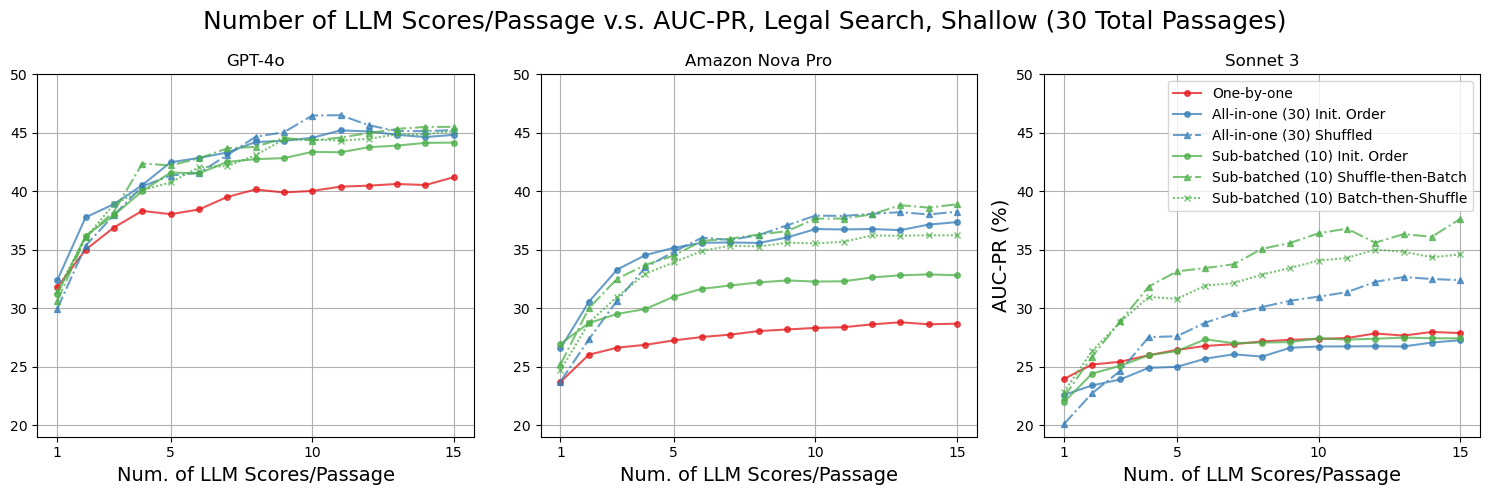

In [14]:
#ribbon 4o legal
fig_title = 'Number of LLM Scores/Passage v.s. AUC-PR, Legal Search, Shallow (30 Total Passages)'

ax_titles = ['GPT-4o', 'Amazon Nova Pro', 'Sonnet 3']

#cols
llms = ['4o/temp_1', 'nova/temp_1', 'sonnet/temp_1']
#rows
dataset = 'uk_pl_test_set_2'
base_path = '../trials'

method_suffixes = [
    'init_order/30_cand/pw/n_rescores_15/1_amean_der',
    'init_order/30_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean',
    'init_order/30_cand/pw/n_rescores_15/10_amean',
    'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean'
]

method_names = [
    'One-by-one',
    'All-in-one (30) Init. Order',
    'All-in-one (30) Shuffled',
    'Sub-batched (10) Init. Order',
    'Sub-batched (10) Shuffle-then-Batch',
    'Sub-batched (10) Batch-then-Shuffle',
]

metric_label='AUC-PR'
metric_fun = get_auc_pr

y_lims = (19,50)

save_title = 'n_scores_shallow_legal'

# Call the function with the provided inputs
plot_1x3_metric_grid(
    base_path=base_path,
    dataset=dataset,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    y_lims=y_lims,
    save_title=save_title
)


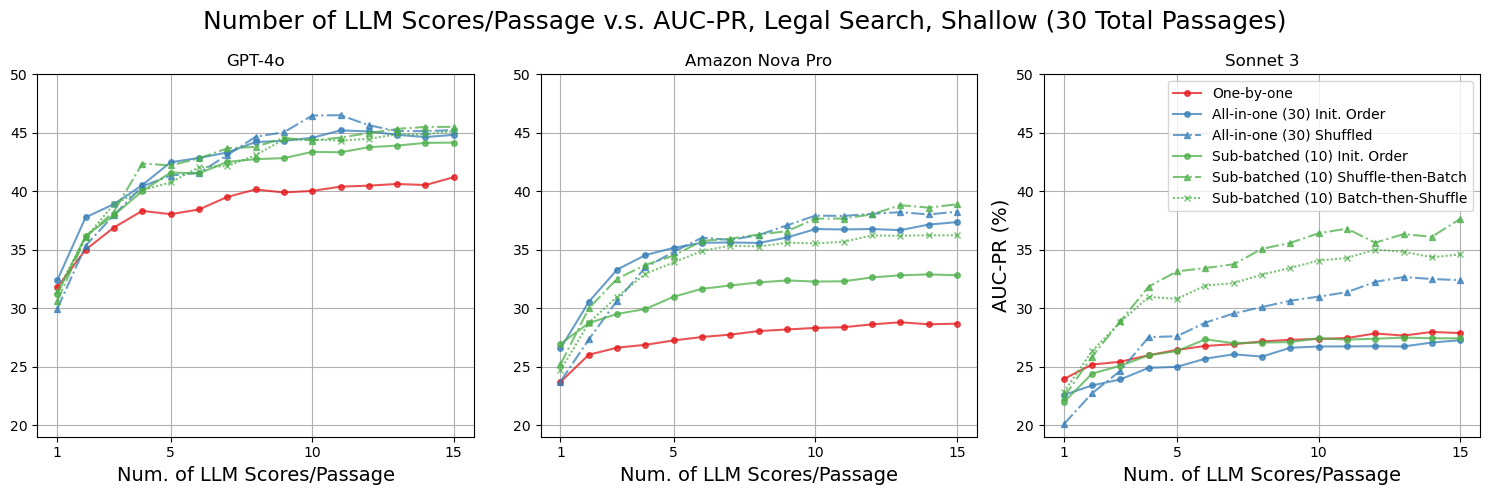

In [15]:
#ribbon 4o legal
fig_title = 'Number of LLM Scores/Passage v.s. AUC-PR, Legal Search, Shallow (30 Total Passages)'

ax_titles = ['GPT-4o', 'Amazon Nova Pro', 'Sonnet 3']

#cols
llms = ['4o/temp_1', 'nova/temp_1', 'sonnet/temp_1']
#rows
dataset = 'uk_pl_test_set_2'
base_path = '../trials'

method_suffixes = [
    'init_order/30_cand/pw/n_rescores_15/1_amean_der',
    'init_order/30_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean',
    'init_order/30_cand/pw/n_rescores_15/10_amean',
    'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean'
]

method_names = [
    'One-by-one',
    'All-in-one (30) Init. Order',
    'All-in-one (30) Shuffled',
    'Sub-batched (10) Init. Order',
    'Sub-batched (10) Shuffle-then-Batch',
    'Sub-batched (10) Batch-then-Shuffle',
]

metric_label='AUC-PR'
metric_fun = get_auc_pr

y_lims = (19,50)

save_title = 'n_scores_shallow_legal'

# Call the function with the provided inputs
plot_1x3_metric_grid(
    base_path=base_path,
    dataset=dataset,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    y_lims=y_lims,
    save_title=save_title
)


# Legal Deep AP Ribbon

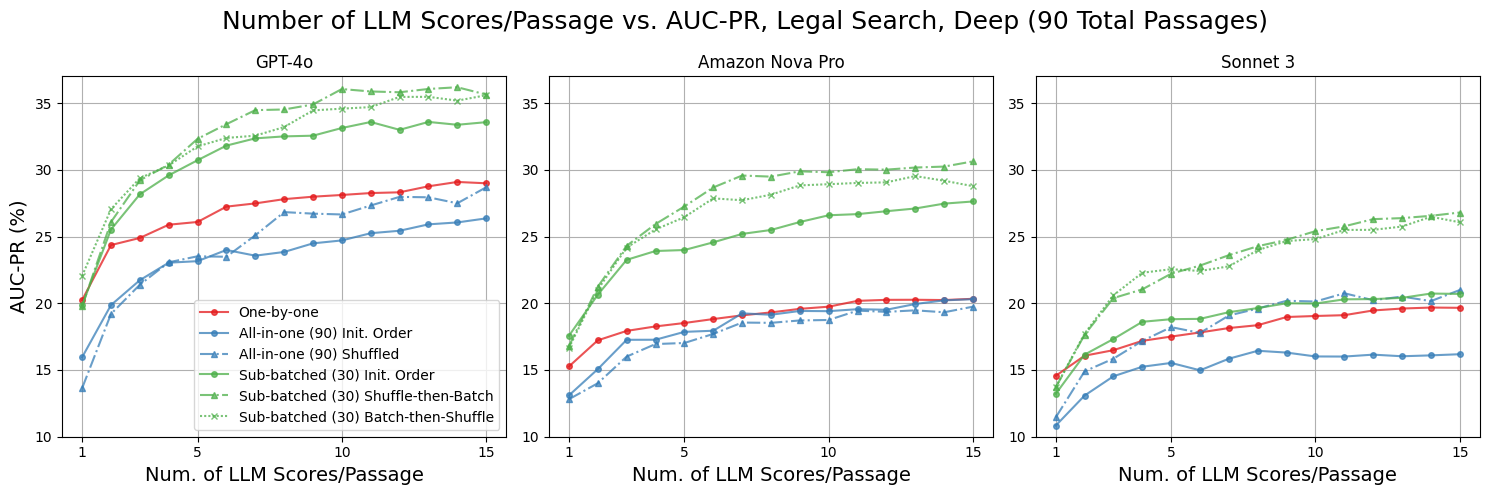

In [136]:
#ribbon 4o legal deep
fig_title = 'Number of LLM Scores/Passage vs. AUC-PR, Legal Search, Deep (90 Total Passages)'

ax_titles = ['GPT-4o', 'Amazon Nova Pro', 'Sonnet 3']

#cols
llms = ['4o/temp_1', 'nova/temp_1', 'sonnet/temp_1']
#rows
dataset = 'uk_pl_test_set_2'
base_path = '../trials'

method_suffixes = [
    'init_order/90_cand/pw/n_rescores_15/1_amean',
    'init_order/90_cand/pw/n_rescores_15/90_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean',
    'init_order/90_cand/pw/n_rescores_15/30_amean',
    'rand_inter_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/30_amean'
]

method_names = [
    'One-by-one',
    'All-in-one (90) Init. Order',
    'All-in-one (90) Shuffled',
    'Sub-batched (30) Init. Order',
    'Sub-batched (30) Shuffle-then-Batch',
    'Sub-batched (30) Batch-then-Shuffle',
]

metric_label='AUC-PR'
metric_fun = get_auc_pr

y_lims = (10,37)

save_title = 'n_scores_deep_legal'


# Call the function with the provided inputs
plot_1x3_metric_grid(
    base_path=base_path,
    dataset=dataset,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    y_lims=y_lims,
    save_title=save_title
)


# 30 Cands AUC Grid

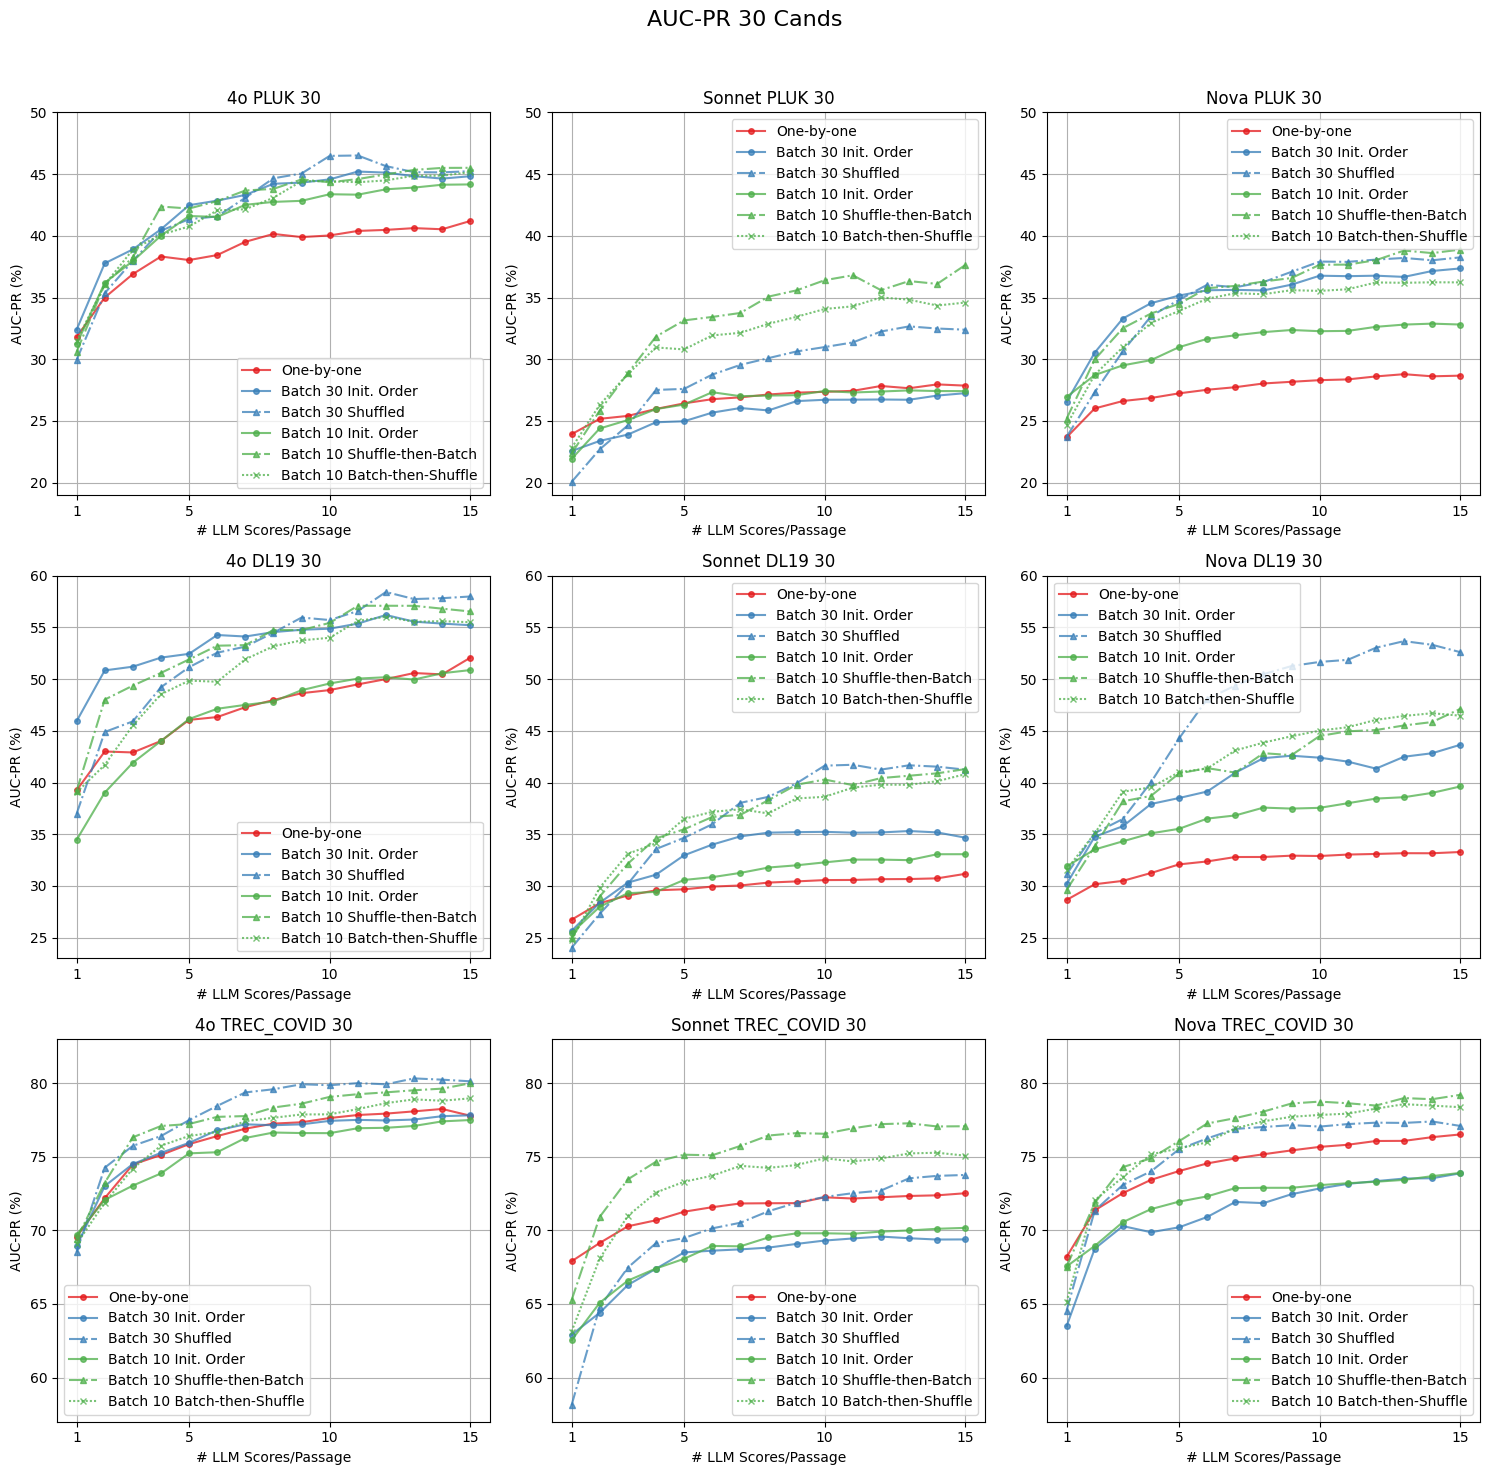

In [ ]:
fig_title = 'AUC-PR 30 Cands'

ax_titles = [['4o Legal Search 30','Sonnet Legal Search 30', 'Nova Legal Search 30'],
            ['4o DL19 30','Sonnet DL19 30', 'Nova DL19 30'],
            ['4o TREC_COVID 30','Sonnet TREC_COVID 30', 'Nova TREC_COVID 30'],

]

#cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
#rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'

method_suffixes = [
    'init_order/30_cand/pw/n_rescores_15/1_amean_der',
    'init_order/30_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean',
    'init_order/30_cand/pw/n_rescores_15/10_amean',
    'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean'
]

method_names = [
    'One-by-one',
    'Batch 30 Init. Order',
    'Batch 30 Shuffled',
    'Batch 10 Init. Order',
    'Batch 10 Shuffle-then-Batch',
    'Batch 10 Batch-then-Shuffle',
]

metric_label='AUC-PR'
metric_fun = get_auc_pr

row_ylims = [(19,50),(23,60),(57,83)]

# Call the function with the provided inputs
plot_3x3_metric_grid(
    base_path=base_path,
    datasets=datasets,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    row_ylims=row_ylims
)


# 90 Cands AUC Grid

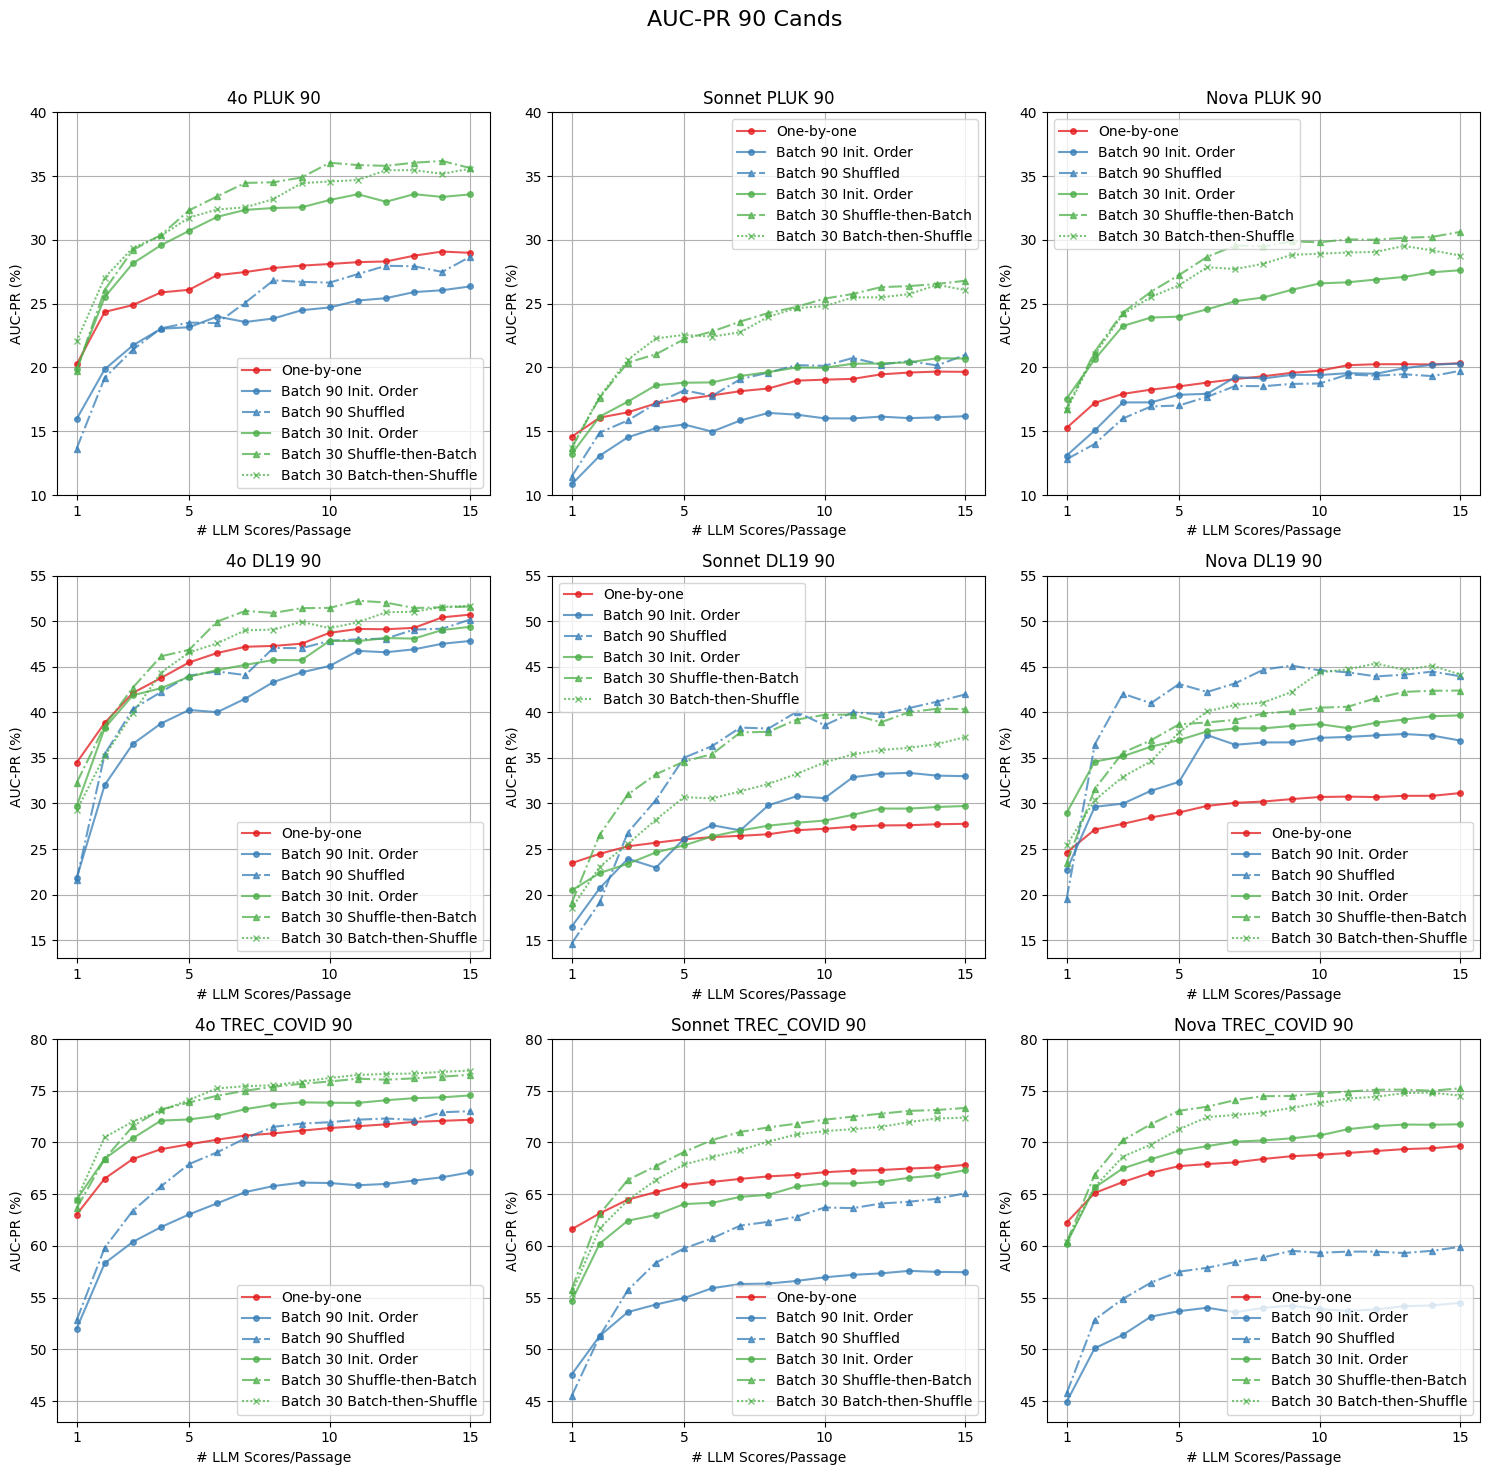

In [ ]:
fig_title = 'AUC-PR 90 Cands'

ax_titles = [['4o Legal Search 90','Sonnet Legal Search 90', 'Nova Legal Search 90'],
            ['4o DL19 90','Sonnet DL19 90', 'Nova DL19 90'],
            ['4o TREC_COVID 90','Sonnet TREC_COVID 90', 'Nova TREC_COVID 90'],
]

#cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
#rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'

method_suffixes = [
    'init_order/90_cand/pw/n_rescores_15/1_amean',
    'init_order/90_cand/pw/n_rescores_15/90_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean',
    'init_order/90_cand/pw/n_rescores_15/30_amean',
    'rand_inter_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/30_amean'
]

method_names = [
    'One-by-one',
    'Batch 90 Init. Order',
    'Batch 90 Shuffled',
    'Batch 30 Init. Order',
    'Batch 30 Shuffle-then-Batch',
    'Batch 30 Batch-then-Shuffle',
]

metric_label='AUC-PR'
metric_fun = get_auc_pr

row_ylims = [(10,40),(13,55),(43,80)]

# Call the function with the provided inputs
plot_3x3_metric_grid(
    base_path=base_path,
    datasets=datasets,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    row_ylims=row_ylims
)


# N_scores AUC-PR Table

In [67]:
#global (30 cands and 90 cands data)
##cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
##rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'

metric_fun = get_auc_pr

#30 Cand Data
thirty_cand_method_suffixes = [
    'init_order/30_cand/pw/n_rescores_15/1_amean_der',
    'init_order/30_cand/pw/n_rescores_15/10_amean',
    'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order/30_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean',
]

#90 Cand Data
ninety_cand_method_suffixes = [
    'init_order/90_cand/pw/n_rescores_15/1_amean',
    'init_order/90_cand/pw/n_rescores_15/30_amean',
    'rand_inter_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
    'init_order/90_cand/pw/n_rescores_15/90_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean',
]

n_scores_latex_code = generate_ensemble_latex_table(
    base_path,
    datasets,
    llms,
    thirty_cand_method_suffixes,
    ninety_cand_method_suffixes
)

In [57]:
print(n_scores_latex_code)

\begin{table*}[t]
\scriptsize
\centering
\caption{Ensembling}
\label{tab:ensembling}
\begin{tabular}{|c|c|c||c|c|c||c|c|c||c|c|c||}
\cline{2-12}
\multicolumn{1}{c|}{} & & & \multicolumn{3}{c||}{\textbf{Legal}} & \multicolumn{3}{c||}{\textbf{DL-19}} & \multicolumn{3}{c||}{\textbf{Covid}} \\
\cline{4-12}
\multicolumn{1}{c|}{} & \textbf{Batch} & \textbf{Psg.} & \textbf{GPT-4o} & \textbf{Sonnet} & \textbf{Nova} & \textbf{GPT-4o} & \textbf{Sonnet} & \textbf{Nova} & \textbf{GPT-4o} & \textbf{Sonnet} & \textbf{Nova} \\
\multicolumn{1}{c|}{} & \textbf{Size} & \textbf{Order} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} & AP\textsuperscript{1}/AP\textsuperscript{15} \\
\

# NDCG@10 Table

In [38]:
#global (30 cands and 90 cands data)
##cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
##rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'


ndcg_latex_table = generate_ndcg_latex_table(
    base_path,
    datasets,
    llms,
    [
        'initial',
        'init_order/30_cand/lw/n_rescores_1/lw_simple',
        'init_order_w_in_batch_shuf/30_cand/lw/n_rescores_1/lw_simple',
        'init_order/30_cand/lw/n_rescores_15/lw_agg_kemeny_young',
        'init_order_w_in_batch_shuf/30_cand/lw/n_rescores_15/lw_agg_kemeny_young',
        'init_order/30_cand/pw/n_rescores_1/1_amean_der',
        'init_order/30_cand/pw/n_rescores_15/1_amean_der',
        'init_order/30_cand/pw/n_rescores_1/10_amean_der',
        'rand_inter_batch_shuf/30_cand/pw/n_rescores_1/10_amean_der',
        'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_1/10_amean_der',
        'init_order/30_cand/pw/n_rescores_15/10_amean',
        'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
        'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
        'init_order/30_cand/pw/n_rescores_1/30_amean_der',
        'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_1/30_amean_der',
        'init_order/30_cand/pw/n_rescores_15/30_amean',
        'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean'
    ],
    [
        'initial',
        'init_order/90_cand/lw/n_rescores_1/lw_simple',
        'init_order_w_in_batch_shuf/90_cand/lw/n_rescores_1/lw_simple',
        'init_order/90_cand/lw/n_rescores_15/lw_agg_kemeny_young',
        'init_order_w_in_batch_shuf/90_cand/lw/n_rescores_15/lw_agg_kemeny_young',
        'init_order/90_cand/pw/n_rescores_1/1_amean_der',
        'init_order/90_cand/pw/n_rescores_15/1_amean',
        'init_order/90_cand/pw/n_rescores_1/30_amean_der',
        'rand_inter_batch_shuf/90_cand/pw/n_rescores_1/30_amean_der',
        'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_1/30_amean_der',
        'init_order/90_cand/pw/n_rescores_15/30_amean',
        'rand_inter_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
        'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
        'init_order/90_cand/pw/n_rescores_1/90_amean_der',
        'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_1/90_amean_der',
        'init_order/90_cand/pw/n_rescores_15/90_amean',
        'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean'
    ]
)


In [ ]:
print(ndcg_latex_table)

\begin{table*}[t]
\scriptsize
\centering
\caption{Ensembling with 22 Methods}
\label{tab:ensembling_v2}
\begin{tabular}{|c|c|c|c|r||c|c|c||c|c|c||c|c|c||}
\cline{2-14}
\multicolumn{1}{c|}{} & & & & & \multicolumn{3}{c||}{\textbf{Legal}} & \multicolumn{3}{c||}{\textbf{DL-19}} & \multicolumn{3}{c||}{\textbf{Covid}} \\
\cline{6-14}
\multicolumn{1}{c|}{} & \textbf{Batch} & \textbf{Psg.} & & & \textbf{GPT-4o} & \textbf{Sonnet} & \textbf{Nova} & \textbf{GPT-4o} & \textbf{Sonnet} & \textbf{Nova} & \textbf{GPT-4o} & \textbf{Sonnet} & \textbf{Nova} \\
\Xhline{4\arrayrulewidth}
\multirow{11}{*}{\rotatebox{90}{30 Tot. Psgs.}}
 &  &  &  &  & 37.2 & 37.2 & 37.2 & 50.6 & 50.6 & 50.6 & 59.5 & 59.5 & 59.5 \\
 &  &  &  &  & 46.2 & 41.6 & 44.5 & 65.9 & 65.2 & 61.9 & 73.4 & 66.4 & 67.9 \\
 &  &  &  &  & 13.9 & 12.6 & 13.8 & 34.6 & 36.0 & 34.6 & 45.7 & 47.5 & 48.3 \\
 &  &  &  &  & 48.9 & 45.1 & 46.7 & 67.4 & 66.7 & 63.6 & 74.6 & 70.5 & 70.3 \\
 &  &  &  &  & 13.9 & 15.3 & 13.3 & 33.0 & 30.4 & 30.8 & 45.0

: 

# TREC Ribbon Legal Shallow

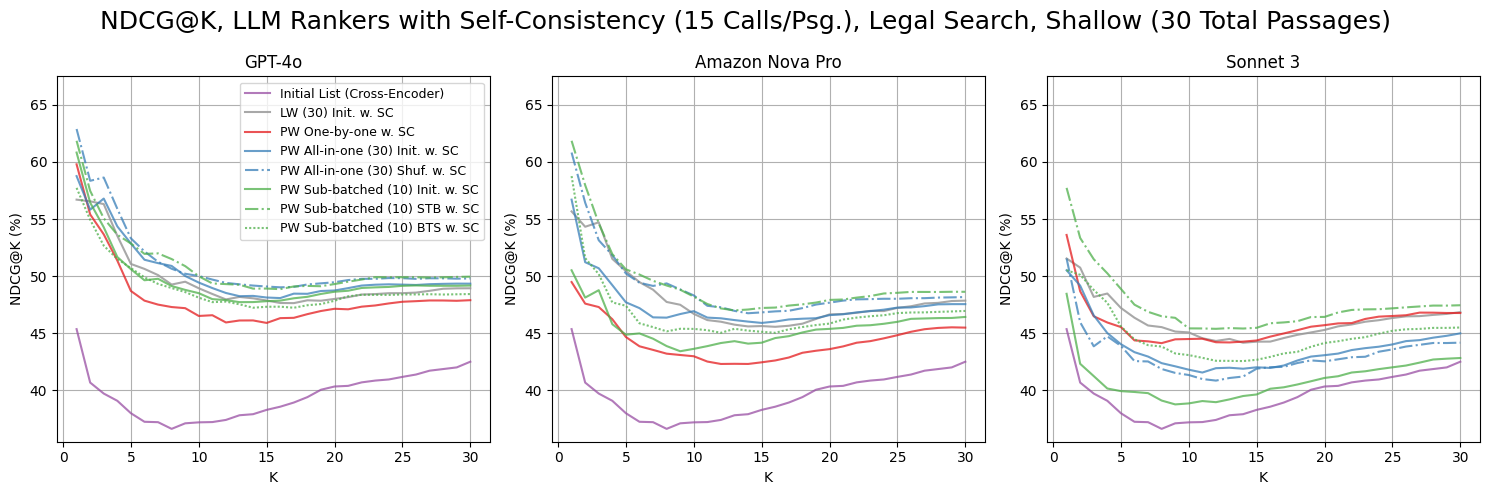

In [137]:
# Ribbon for NDCG@k (Legal Shallow)
fig_title = 'NDCG@K, LLM Rankers with Self-Consistency (15 Calls/Psg.), Legal Search, Shallow (30 Total Passages)'

ax_titles = ['GPT-4o', 'Amazon Nova Pro', 'Sonnet 3']

# Columns (LLMs)
llms = ['4o/temp_1', 'nova/temp_1', 'sonnet/temp_1']
# Rows (Dataset)
dataset = 'uk_pl_test_set_2'
base_path = '../trials'

method_suffixes = [
    '../trials/uk_pl_test_set_2/ce',
    #'init_order/30_cand/pw/n_rescores_1/1_amean_der',
    'init_order/30_cand/lw/n_rescores_15/lw_agg_kemeny_young',
    'init_order/30_cand/pw/n_rescores_15/1_amean_der',
    #'init_order/30_cand/lw/n_rescores_1/lw_simple',
    'init_order/30_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean',
    'init_order/30_cand/pw/n_rescores_15/10_amean',
    'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
]

method_names = [
    'Initial List (Cross-Encoder)',
    #'One-by-one PW',
    'LW (30) Init. w. SC',    
    'PW One-by-one w. SC',
    #'LW Init.',
    'PW All-in-one (30) Init. w. SC',
    'PW All-in-one (30) Shuf. w. SC',
    'PW Sub-batched (10) Init. w. SC',
    'PW Sub-batched (10) STB w. SC',
    'PW Sub-batched (10) BTS w. SC',
]

metric_label = 'NDCG@K (%)'
metric_fun = get_ndcg_up_to_k

k = 30 # Values of k for NDCG@k
y_lims = (35.5, 67.5)

save_title = 'ndcg_k_shallow_legal'

# Call the function with the provided inputs
plot_1x3_metric_grid(
    base_path=base_path,
    dataset=dataset,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    f_plot = plot_trec_metric_on_ax,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    k = k,
    y_lims=y_lims,
    save_title=save_title,
    include_initial_list = True
)

# TREC Ribbon Legal Deep

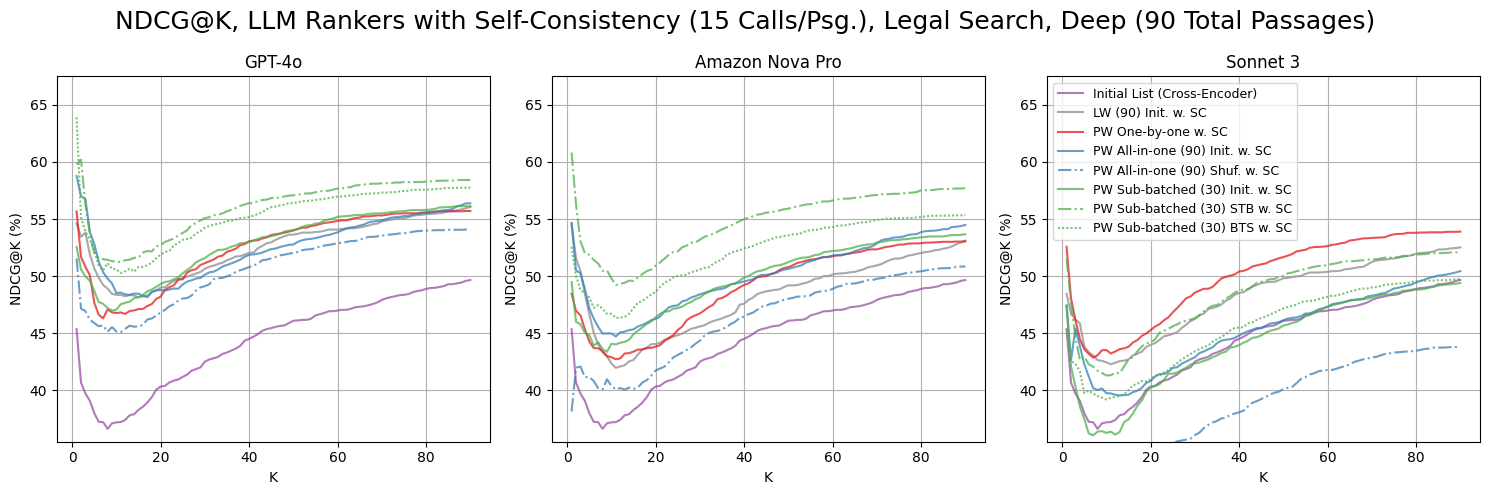

In [144]:
# Ribbon for NDCG@k (Legal Shallow)
fig_title = 'NDCG@K, LLM Rankers with Self-Consistency (15 Calls/Psg.), Legal Search, Deep (90 Total Passages)'

ax_titles = ['GPT-4o', 'Amazon Nova Pro', 'Sonnet 3']

# Columns (LLMs)
llms = ['4o/temp_1', 'nova/temp_1', 'sonnet/temp_1']
# Rows (Dataset)
dataset = 'uk_pl_test_set_2'
base_path = '../trials'

method_suffixes = [
    '../trials/uk_pl_test_set_2/ce',
    #'init_order/90_cand/pw/n_rescores_1/1_amean_der',
    'init_order/90_cand/lw/n_rescores_15/lw_agg_kemeny_young',
    'init_order/90_cand/pw/n_rescores_15/1_amean',
    #'init_order/90_cand/lw/n_rescores_1/lw_simple',
    'init_order/90_cand/pw/n_rescores_15/90_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean',
    'init_order/90_cand/pw/n_rescores_15/30_amean',
    'rand_inter_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
]

method_names = [
    'Initial List (Cross-Encoder)',
    #'One-by-one PW',    
    'LW (90) Init. w. SC',
    'PW One-by-one w. SC',
    #'LW Init.',
    'PW All-in-one (90) Init. w. SC',
    'PW All-in-one (90) Shuf. w. SC',
    'PW Sub-batched (30) Init. w. SC',
    'PW Sub-batched (30) STB w. SC',
    'PW Sub-batched (30) BTS w. SC',
]

metric_label = 'NDCG@K (%)'
metric_fun = get_ndcg_up_to_k

k = 90 # Values of k for NDCG@k
y_lims = (35.5, 67.5)

save_title = 'ndcg_k_deep_legal'

# Call the function with the provided inputs
plot_1x3_metric_grid(
    base_path=base_path,
    dataset=dataset,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    f_plot = plot_trec_metric_on_ax,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    k = k,
    y_lims=y_lims,
    save_title=save_title,
    include_initial_list = True
)

# 30 Cands NDCG Grid

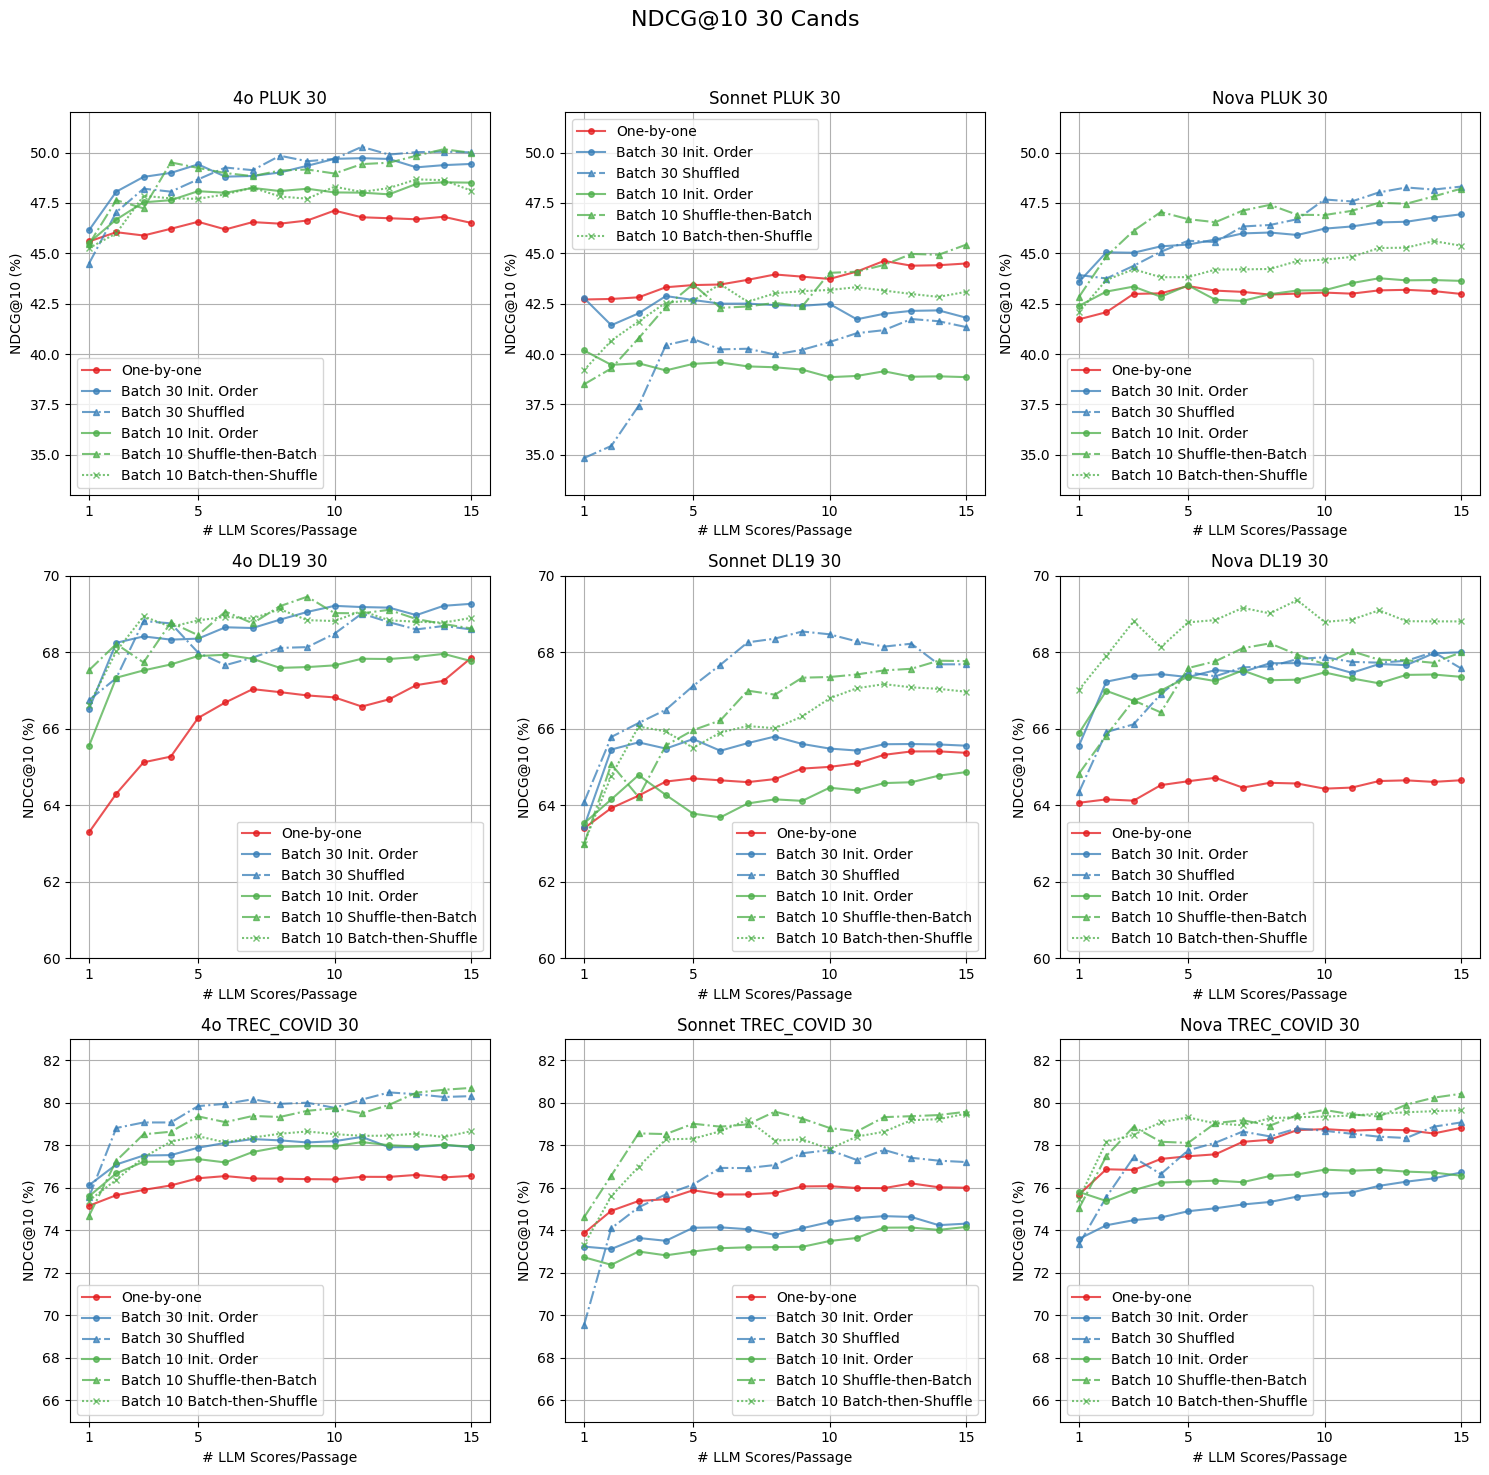

In [ ]:
#30 ndcg@10
fig_title = 'NDCG@10 30 Cands'

ax_titles = [['4o Legal Search 30','Sonnet Legal Search 30', 'Nova Legal Search 30'],
            ['4o DL19 30','Sonnet DL19 30', 'Nova DL19 30'],
            ['4o TREC_COVID 30','Sonnet TREC_COVID 30', 'Nova TREC_COVID 30'],
]

#cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
#rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'

method_suffixes = [
    'init_order/30_cand/pw/n_rescores_15/1_amean_der',
    'init_order/30_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean',
    'init_order/30_cand/pw/n_rescores_15/10_amean',
    'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean'
]

method_names = [
    'One-by-one',
    'Batch 30 Init. Order',
    'Batch 30 Shuffled',
    'Batch 10 Init. Order',
    'Batch 10 Shuffle-then-Batch',
    'Batch 10 Batch-then-Shuffle',
]

metric_label='NDCG@10'
metric_fun = get_ndcg_at_10

row_ylims = [(33,52),(60,70),(65,83)]

# Call the function with the provided inputs
plot_3x3_metric_grid(
    base_path=base_path,
    datasets=datasets,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    row_ylims=row_ylims
)


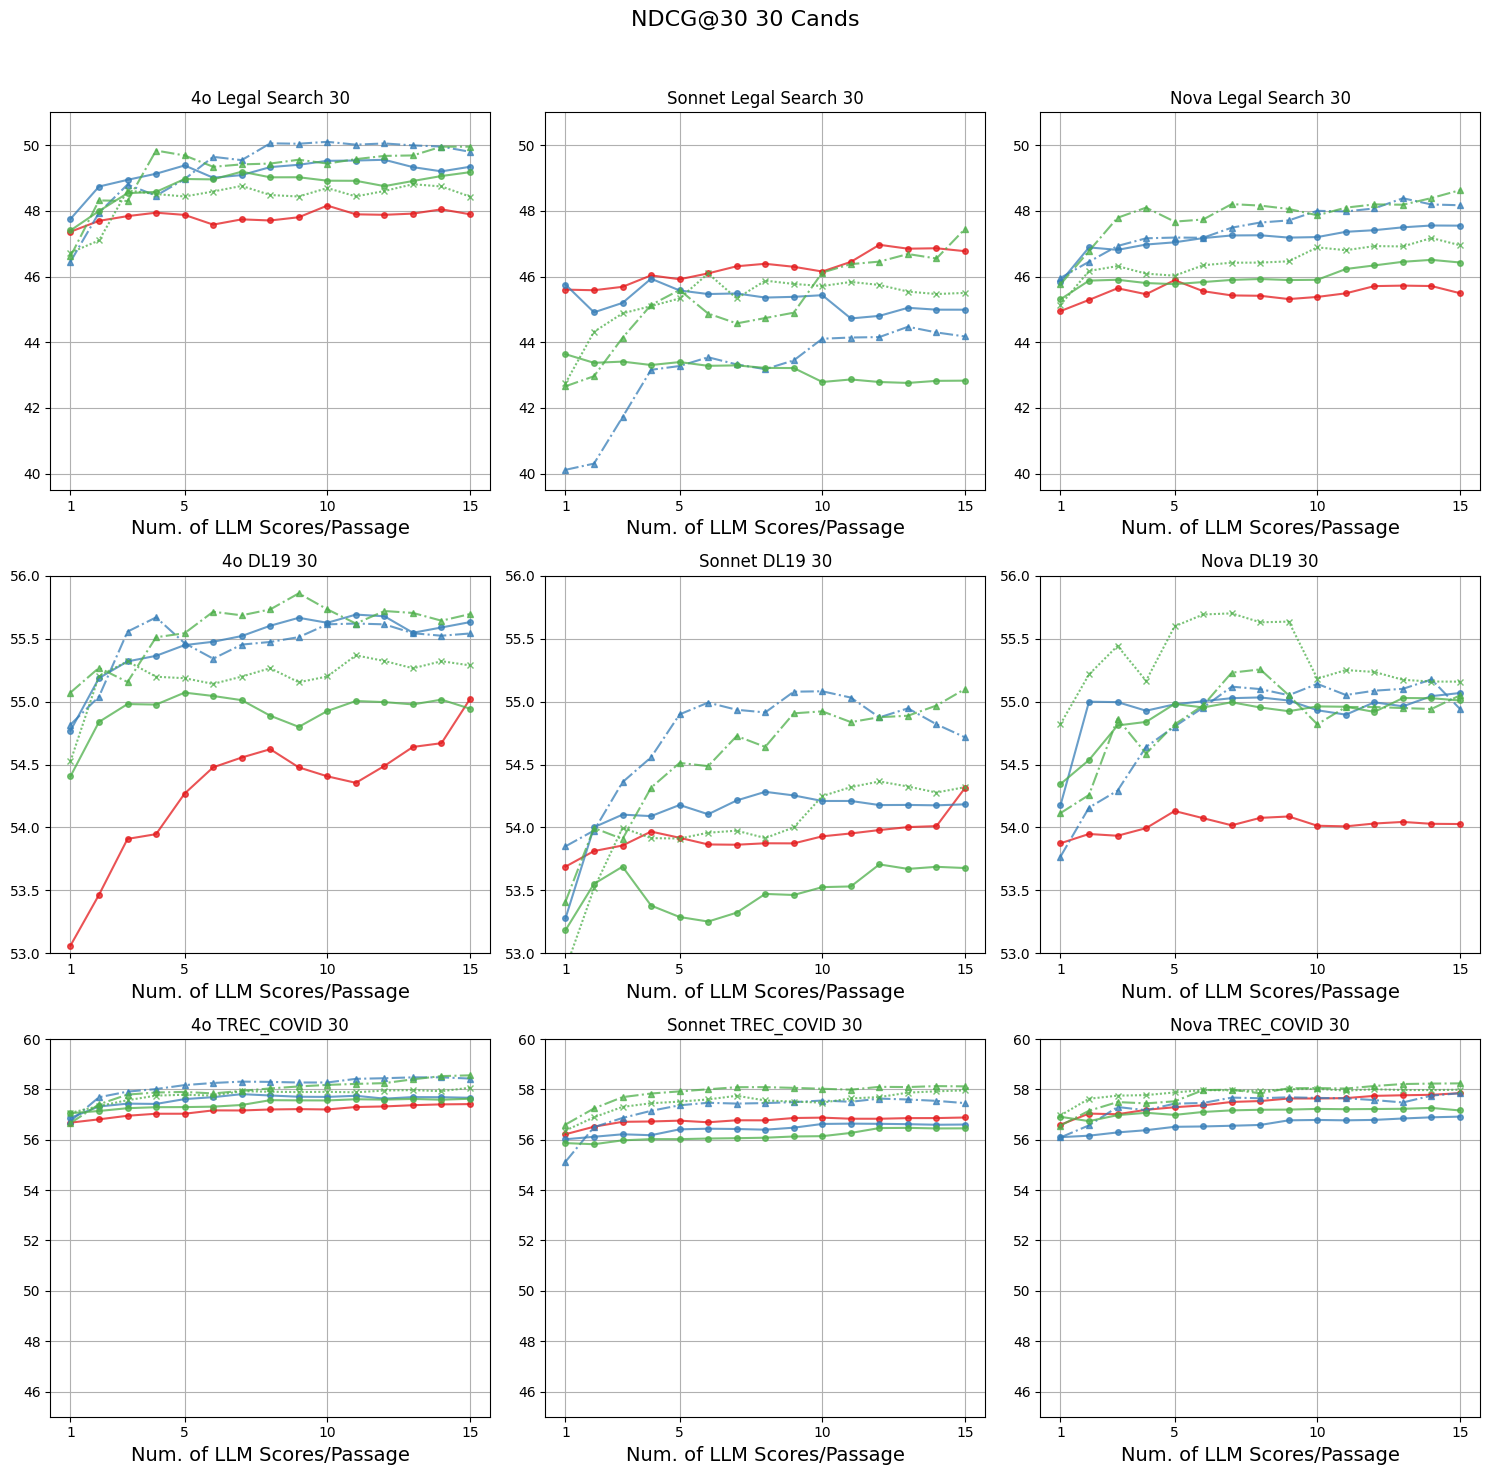

In [149]:
#30 ndcg@30
fig_title = 'NDCG@30 30 Cands'

ax_titles = [['4o Legal Search 30','Sonnet Legal Search 30', 'Nova Legal Search 30'],
            ['4o DL19 30','Sonnet DL19 30', 'Nova DL19 30'],
            ['4o TREC_COVID 30','Sonnet TREC_COVID 30', 'Nova TREC_COVID 30'],
]

#cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
#rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'

method_suffixes = [
    'init_order/30_cand/pw/n_rescores_15/1_amean_der',
    'init_order/30_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/30_amean',
    'init_order/30_cand/pw/n_rescores_15/10_amean',
    'rand_inter_batch_shuf/30_cand/pw/n_rescores_15/10_amean',
    'init_order_w_in_batch_shuf/30_cand/pw/n_rescores_15/10_amean'
]

method_names = [
    'One-by-one',
    'Batch 30 Init. Order',
    'Batch 30 Shuffled',
    'Batch 10 Init. Order',
    'Batch 10 Shuffle-then-Batch',
    'Batch 10 Batch-then-Shuffle',
]

metric_label='NDCG@30'
metric_fun = get_ndcg_at_30

row_ylims = [(39.5,51),(53,56),(45,60)]

# Call the function with the provided inputs
plot_3x3_metric_grid(
    base_path=base_path,
    datasets=datasets,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    row_ylims=row_ylims
)


# NDCG@10 90 Cands

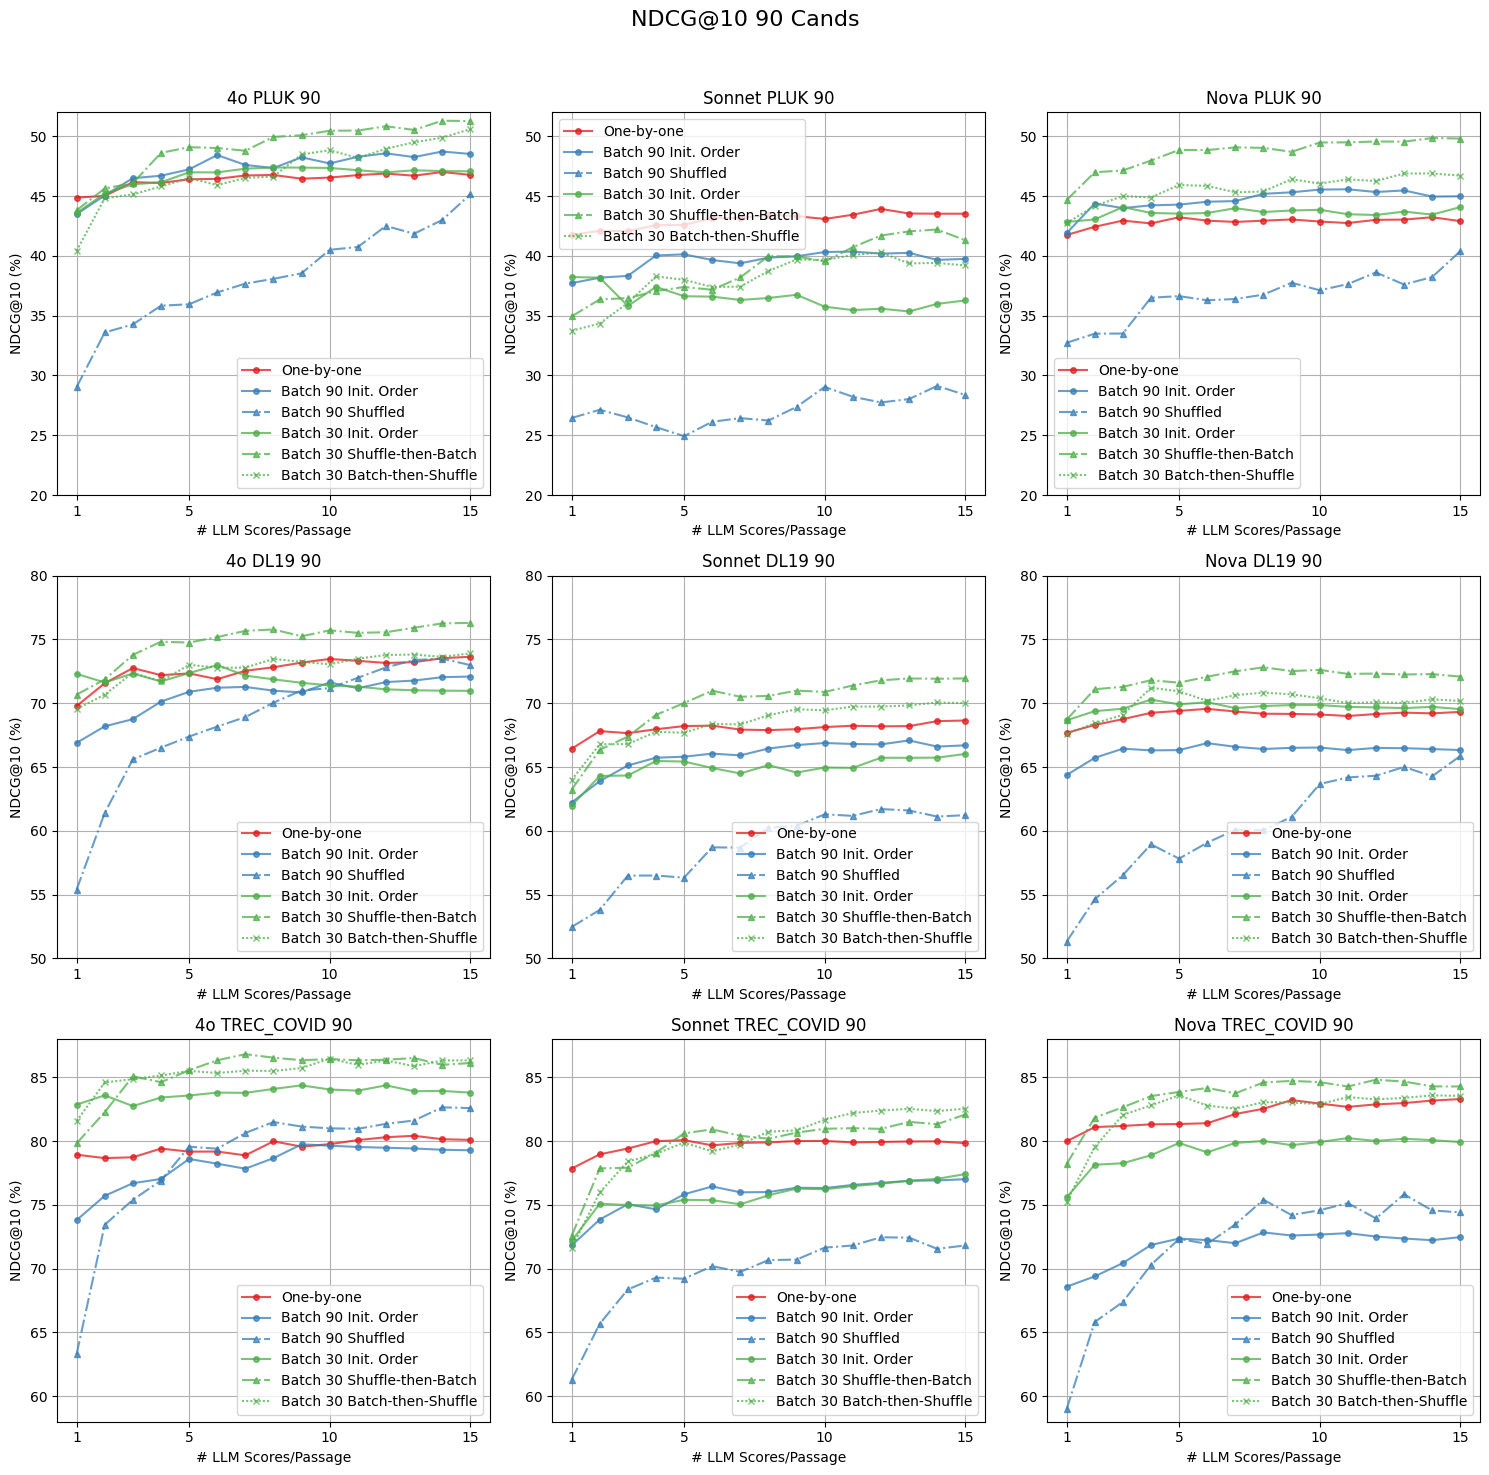

In [ ]:
#90 ndcg@10
fig_title = 'NDCG@10 90 Cands'

ax_titles = [['4o Legal Search 90','Sonnet Legal Search 90', 'Nova Legal Search 90'],
            ['4o DL19 90','Sonnet DL19 90', 'Nova DL19 90'],
            ['4o TREC_COVID 90','Sonnet TREC_COVID 90', 'Nova TREC_COVID 90'],
]

#cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
#rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'

method_suffixes = [
    'init_order/90_cand/pw/n_rescores_15/1_amean',
    'init_order/90_cand/pw/n_rescores_15/90_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean',
    'init_order/90_cand/pw/n_rescores_15/30_amean',
    'rand_inter_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/30_amean'
]

method_names = [
    'One-by-one',
    'Batch 90 Init. Order',
    'Batch 90 Shuffled',
    'Batch 30 Init. Order',
    'Batch 30 Shuffle-then-Batch',
    'Batch 30 Batch-then-Shuffle',
]

metric_label='NDCG@10'
metric_fun = get_ndcg_at_10

row_ylims = [(20,52),(50,80),(58,88)]

# Call the function with the provided inputs
plot_3x3_metric_grid(
    base_path=base_path,
    datasets=datasets,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    row_ylims=row_ylims
)


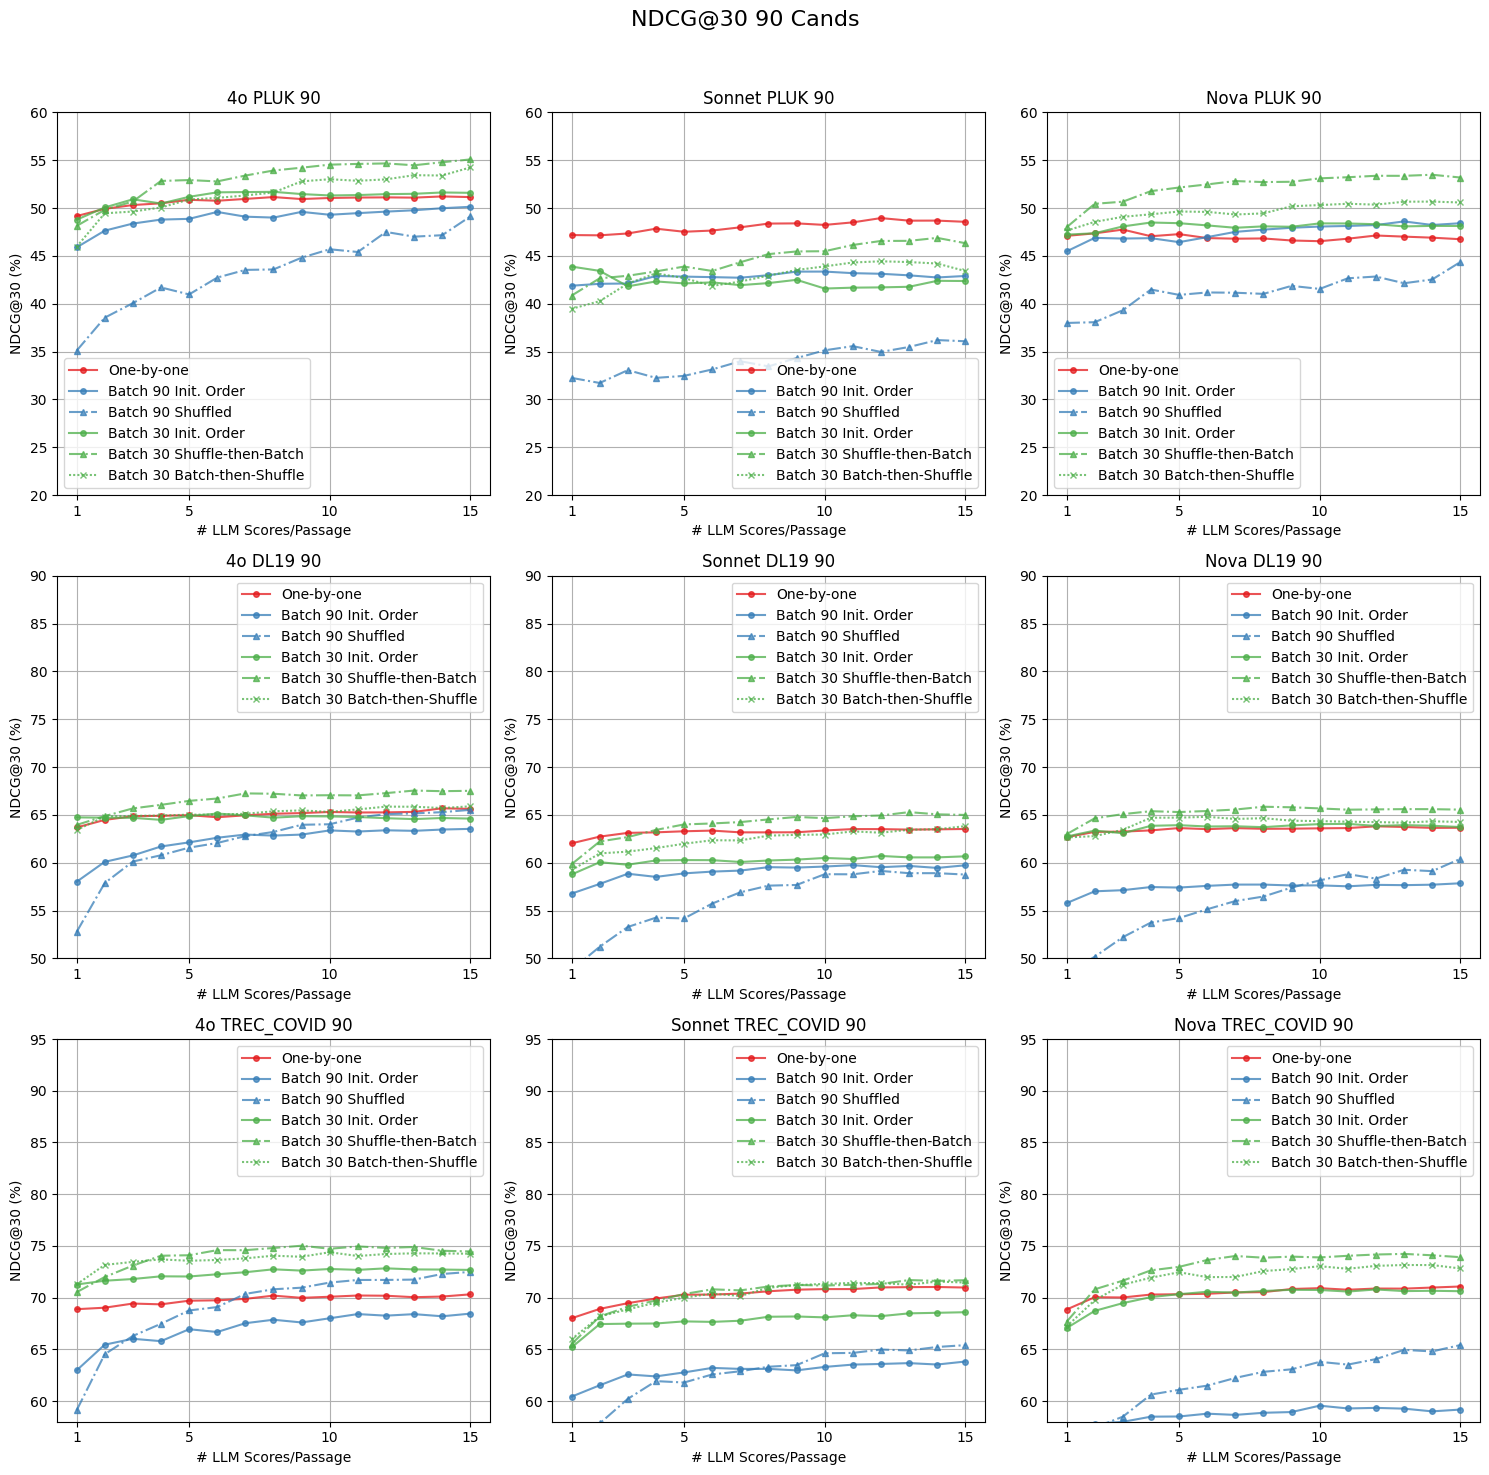

In [ ]:
#90 ndcg@30
fig_title = 'NDCG@30 90 Cands'

ax_titles = [['4o Legal Search 90','Sonnet Legal Search 90', 'Nova Legal Search 90'],
            ['4o DL19 90','Sonnet DL19 90', 'Nova DL19 90'],
            ['4o TREC_COVID 90','Sonnet TREC_COVID 90', 'Nova TREC_COVID 90'],
]

#cols
llms = ['4o/temp_1', 'sonnet/temp_1', 'nova/temp_1']
#rows
datasets = ['uk_pl_test_set_2','dl19_bm25','trec_covid_bm25']
base_path = '../trials'

method_suffixes = [
    'init_order/90_cand/pw/n_rescores_15/1_amean',
    'init_order/90_cand/pw/n_rescores_15/90_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean',
    'init_order/90_cand/pw/n_rescores_15/30_amean',
    'rand_inter_batch_shuf/90_cand/pw/n_rescores_15/30_amean',
    'init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/30_amean'
]

method_names = [
    'One-by-one',
    'Batch 90 Init. Order',
    'Batch 90 Shuffled',
    'Batch 30 Init. Order',
    'Batch 30 Shuffle-then-Batch',
    'Batch 30 Batch-then-Shuffle',
]

metric_label='NDCG@30'
metric_fun = get_ndcg_at_30

row_ylims = [(20,60),(50,90),(58,95)]

# Call the function with the provided inputs
plot_3x3_metric_grid(
    base_path=base_path,
    datasets=datasets,
    llms=llms,
    method_suffixes=method_suffixes,
    method_names=method_names,
    get_metric=metric_fun,
    metric_label=metric_label,
    ax_titles=ax_titles,
    fig_title=fig_title,
    row_ylims=row_ylims
)

# 4o Legal Search, 90 

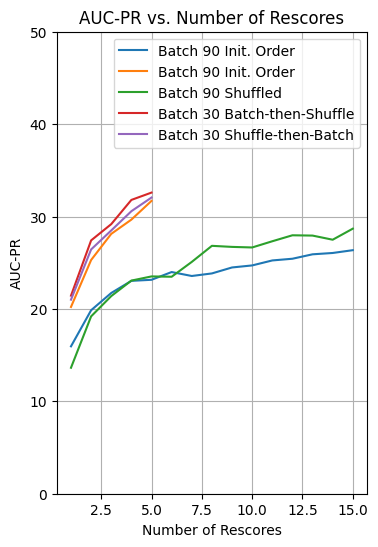

In [ ]:

method_paths = [
    #'../trials/uk_pl_test_set_2/4o/temp_1/init_order/90_cand/pw/n_rescores_15/1_amean',
    '../trials/uk_pl_test_set_2/4o/temp_1/init_order/90_cand/pw/n_rescores_15/90_amean',
    '../trials/uk_pl_test_set_2/4o/temp_1/init_order/90_cand/pw/n_rescores_5/30_amean',
    '../trials/uk_pl_test_set_2/4o/temp_1/init_order_w_in_batch_shuf/90_cand/pw/n_rescores_15/90_amean',
    '../trials/uk_pl_test_set_2/4o/temp_1/init_order_w_in_batch_shuf/90_cand/pw/n_rescores_5/30_amean',
    '../trials/uk_pl_test_set_2/4o/temp_1/rand_inter_batch_shuf/90_cand/pw/n_rescores_5/30_amean'
]
method_names = [
    #'One-by-one',
    'Batch 90 Init. Order',
    'Batch 90 Init. Order',
    'Batch 90 Shuffled',
    'Batch 30 Batch-then-Shuffle',
    'Batch 30 Shuffle-then-Batch',
]

plot_single_metric(
    method_paths,
    method_names,
    get_auc_pr,
    metric_label='AUC-PR',
    k = 15,
    y_lim=(0, 50)
)